In [1]:
import gifba
from scipy.integrate import solve_ivp
import numpy as np
import cobra as cb
import pandas as pd
from IPython.display import clear_output
import copy
import matplotlib.pyplot as plt
from cobra import Model
import os
from pathlib import Path
import json

In [ ]:
# import all files from benchmark_results
RESULTS_DIR = Path(os.getcwd()) / "benchmark_results"
REPLACE_DNF_WITH = 4 * 3600 # value to replace NAN for solve_ivp_time for incomplete simulations (4 hours)

# Load all JSON files in the results directory
results = {
    file.stem: json.loads(file.read_text())
    for file in RESULTS_DIR.glob("*.json")
}
df = pd.DataFrame.from_dict(results, orient="index")

df = df.dropna(subset=['dfba_status', 'status'], how="all")

df["dfba_status"] = df["status"].fillna(df["dfba_status"])
df = df.drop(columns=["status"])

# address incomplete sims
pattern = r"^(dfba_complete|dfba_in_progress_\d*000)$"
df = df[df["dfba_status"].astype(str).str.match(pattern, na=False)]
df.loc[df["dfba_status"].str.startswith("dfba_in_progress_"), "solve_ivp_time"] = REPLACE_DNF_WITH
df = df.drop(columns=["dfba_status"]) # drop dfba_status column (only used for filtering)

# convert all numeric columns to float
df = df.apply(pd.to_numeric, errors='ignore')

# parse gifba and dfba into separate dfs
gifba_df = df[["N_models", "sum_N_rxns", "sum_N_mets", "gifba_solve_time", "gifba_fba_calls"]].copy()
dfba_df = df[]]

df

/tmp/ipykernel_494124/2242203625.py:24: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df = df.apply(pd.to_numeric, errors='ignore')


,N_models,model_names,sum_N_rxns,sum_N_mets,vmax,km,gifba_solve_time,solve_ivp_time,gifba_fba_calls,dfba_fba_calls,solver_method
5178893_5,2,"[Escherichia_coli_99_0741.mat, Streptococcus_a...",5810,5111,100.0,0.5,41.252388,14400.000000,24.0,11000,RK45
5144057_4,2,[Salmonella_enterica_subsp_enterica_serovar_En...,2923,2457,500.0,0.1,15.241766,428.072685,30.0,28652,BDF
5168957_2,6,"[Escherichia_coli_O157_H7_str_TW14588.mat, Ped...",9066,8034,100.0,0.1,54.493230,14400.000000,366.0,906000,RK45
5144057_1,10,"[Veillonella_sp_oral_taxon_780_str_F0422.mat, ...",21059,18837,100.0,1.0,97.359879,1374.177323,470.0,49950,BDF
5144057_3,2,"[Streptococcus_agalactiae_GB00219.mat, Escheri...",5379,4576,500.0,0.5,32.287525,49.779533,12.0,1298,BDF
5178893_3,2,"[Eggerthella_sp_YY7918.mat, Fusobacterium_nucl...",2116,1987,500.0,1.0,10.168704,297.573947,16.0,25078,RK45
5144057_8,6,[Salmonella_enterica_subsp_enterica_serovar_En...,10110,8949,1000.0,0.5,91.443658,122.721858,324.0,4158,BDF
5168957_7,6,"[Escherichia_coli_88_0221.mat, Klebsiella_pneu...",12437,10979,500.0,0.1,192.511858,14400.000000,450.0,300000,BDF
5168957_8,10,"[Bacillus_cereus_03BB108.mat, Campylobacter_je...",12936,11670,100.0,0.1,413.823586,14400.000000,3140.0,645000,RK45
5168957_5,10,"[Enterococcus_mundtii_QU_25.mat, Cuneatibacter...",14636,13235,100.0,1.0,231.166508,8332.284928,950.0,225500,RK45


In [3]:
# save each model_names in case later is needed
model_names = df['model_names']

df.drop(columns=['model_names'], inplace=True)
df

,N_models,sum_N_rxns,sum_N_mets,vmax,km,gifba_solve_time,solve_ivp_time,gifba_fba_calls,dfba_fba_calls,solver_method
5178893_5,2,5810,5111,100.0,0.5,41.252388,14400.000000,24.0,11000,RK45
5144057_4,2,2923,2457,500.0,0.1,15.241766,428.072685,30.0,28652,BDF
5168957_2,6,9066,8034,100.0,0.1,54.493230,14400.000000,366.0,906000,RK45
5144057_1,10,21059,18837,100.0,1.0,97.359879,1374.177323,470.0,49950,BDF
5144057_3,2,5379,4576,500.0,0.5,32.287525,49.779533,12.0,1298,BDF
5178893_3,2,2116,1987,500.0,1.0,10.168704,297.573947,16.0,25078,RK45
5144057_8,6,10110,8949,1000.0,0.5,91.443658,122.721858,324.0,4158,BDF
5168957_7,6,12437,10979,500.0,0.1,192.511858,14400.000000,450.0,300000,BDF
5168957_8,10,12936,11670,100.0,0.1,413.823586,14400.000000,3140.0,645000,RK45
5168957_5,10,14636,13235,100.0,1.0,231.166508,8332.284928,950.0,225500,RK45


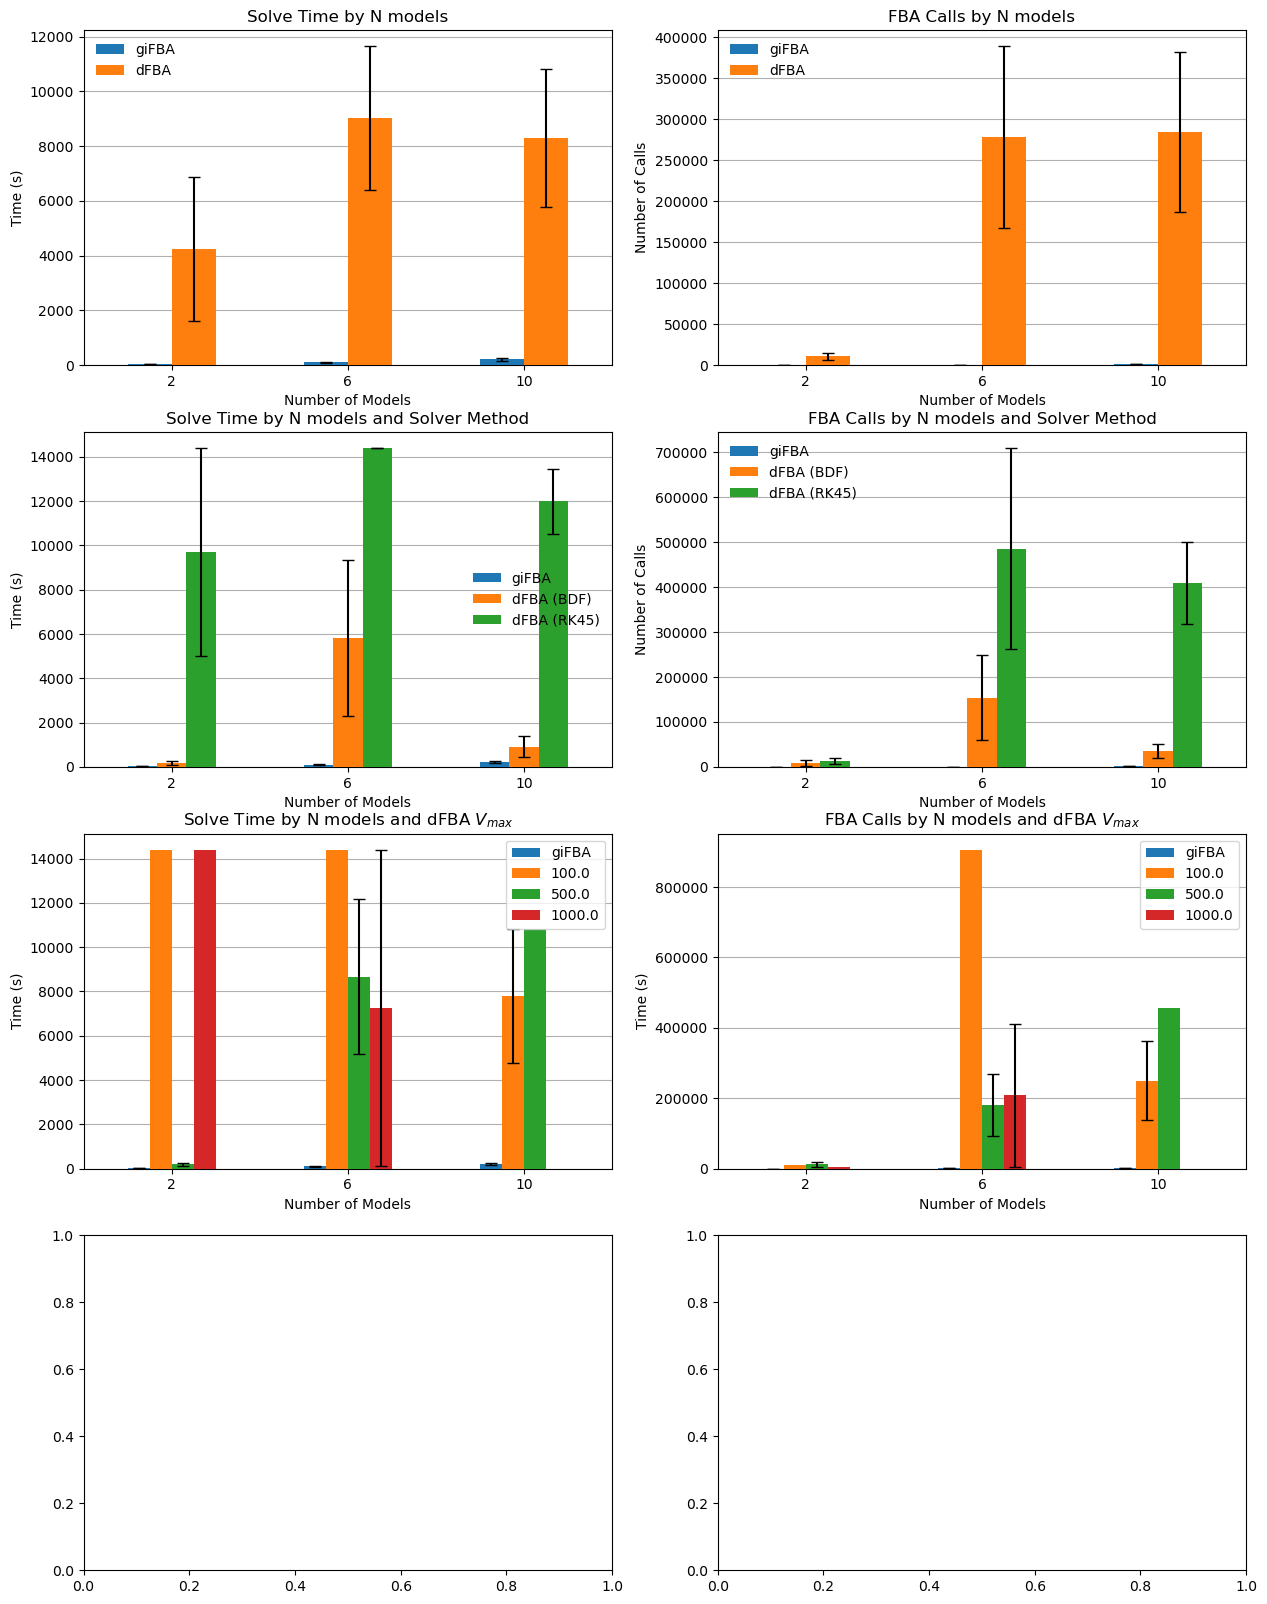

In [8]:
# GIFBA_COLOR = "seagreen"
# DFBA_COLOR = "darkorange"
# RK45_COLOR = "crimson"
# BDF_COLOR = "gold"
Y_SCALE = "linear"

SOLVER_METHODS = df["solver_method"].unique()


continuous_vars = ["N_models", "sum_N_rxns", "sum_N_mets"]
discrete_vars = ["vmax", "km", "solver_method"]
targets = ["gifba_solve_time", "solve_ivp_time", "gifba_fba_calls", "dfba_fba_calls"]

#plotting
fig, axs = plt.subplots(4, 2, figsize=(15, 20))
axs = axs.flatten()

# gifba vs dfba wall clock grouped by N_models
g1_mean = df.groupby("N_models")[["gifba_solve_time", "solve_ivp_time"]].mean()
g1_sem = df.groupby("N_models")[["gifba_solve_time", "solve_ivp_time"]].sem()
g1_mean.plot(
    kind="bar",
    yerr=g1_sem,
    ax=axs[0],
    capsize=4,
    rot=0,
    # color=[GIFBA_COLOR, DFBA_COLOR],
    zorder=3,
)
axs[0].set_title("Solve Time by N models")
axs[0].set_xlabel("Number of Models")
axs[0].set_ylabel("Time (s)")
axs[0].set_yscale(Y_SCALE)
axs[0].grid(axis="y", zorder=0)
axs[0].legend(labels=["giFBA", "dFBA"], frameon=False)

# gifba vs dfba fba calls grouped by N_models
g2_mean = df.groupby("N_models")[["gifba_fba_calls", "dfba_fba_calls"]].mean()
g2_sem = df.groupby("N_models")[["gifba_fba_calls", "dfba_fba_calls"]].sem()
g2_mean.plot(
    kind="bar",
    yerr=g2_sem,
    ax=axs[1],
    capsize=4,
    rot=0,
    # color=[GIFBA_COLOR, DFBA_COLOR],
    zorder=3,
)
axs[1].set_title("FBA Calls by N models")
axs[1].set_xlabel("Number of Models")
axs[1].set_ylabel("Number of Calls")
axs[1].set_yscale(Y_SCALE)
axs[1].grid(axis="y", zorder=0)
axs[1].legend(labels=["giFBA", "dFBA"], frameon=False)

# wall clock times, break up dfba by solver method
ivp_pivot_time = df.pivot_table(
    index="N_models",
    columns="solver_method",
    values="solve_ivp_time",
    aggfunc=["mean", "sem"],
)
gifba_stats_time = df.groupby("N_models")["gifba_solve_time"].agg(["mean", "sem"])
plot_means_time = pd.concat([gifba_stats_time["mean"].rename("giFBA"), ivp_pivot_time["mean"]], axis=1)
plot_sems_time = pd.concat([gifba_stats_time["sem"].rename("giFBA"), ivp_pivot_time["sem"]], axis=1)
plot_means_time.plot(
    kind="bar",
    yerr=plot_sems_time,
    ax=axs[2],
    capsize=4,
    rot=0,
    zorder=3,
    # color=[GIFBA_COLOR, BDF_COLOR, RK45_COLOR],
)
axs[2].set_title("Solve Time by N models and Solver Method")
axs[2].set_xlabel("Number of Models")
axs[2].set_ylabel("Time (s)")
axs[2].set_yscale(Y_SCALE)
axs[2].grid(axis="y", zorder=0)
axs[2].legend(labels=["giFBA", "dFBA (BDF)", "dFBA (RK45)"], frameon=False)

# fba calls, break up dfba by solver method
ivp_pivot_calls = df.pivot_table(
    index="N_models",
    columns="solver_method",
    values="dfba_fba_calls",
    aggfunc=["mean", "sem"],
)
gifba_stats_calls = df.groupby("N_models")["gifba_fba_calls"].agg(["mean", "sem"])
plot_means_calls = pd.concat([gifba_stats_calls["mean"].rename("giFBA"), ivp_pivot_calls["mean"]], axis=1)
plot_sems_calls = pd.concat([gifba_stats_calls["sem"].rename("giFBA"), ivp_pivot_calls["sem"]], axis=1)
plot_means_calls.plot(
    kind="bar",
    yerr=plot_sems_calls,
    ax=axs[3],
    capsize=4,
    rot=0,
    zorder=3,
    # color=[GIFBA_COLOR, BDF_COLOR, RK45_COLOR],
)
axs[3].set_title("FBA Calls by N models and Solver Method")
axs[3].set_xlabel("Number of Models")
axs[3].set_ylabel("Number of Calls")
axs[3].set_yscale(Y_SCALE)
axs[3].grid(axis="y", zorder=0)
axs[3].legend(labels=["giFBA", "dFBA (BDF)", "dFBA (RK45)"], frameon=False)

# plot 5 = 3, but break up by vmax
vmax_pivot_time = df.pivot_table(
    index="N_models",
    columns="vmax",
    values="solve_ivp_time",
    aggfunc=["mean", "sem"],
)
plot_means_time = pd.concat([gifba_stats_time["mean"].rename("giFBA"), vmax_pivot_time["mean"]], axis=1)
plot_sems_time = pd.concat([gifba_stats_time["sem"].rename("giFBA"), vmax_pivot_time["sem"]], axis=1)
plot_means_time.plot(
    kind="bar",
    yerr=plot_sems_time,
    ax=axs[4],
    capsize=4,
    rot=0,
    zorder=3,
    # color=[GIFBA_COLOR, BDF_COLOR, RK45_COLOR],
)
axs[4].set_title(r"Solve Time by N models and dFBA $V_{max}$")
axs[4].set_xlabel("Number of Models")
axs[4].set_ylabel("Time (s)")
axs[4].set_yscale(Y_SCALE)
axs[4].grid(axis="y", zorder=0)
axs[4].legend()
# axs[4].legend(labels=["giFBA", "dFBA (BDF)", "dFBA (RK45)"], frameon=False)

# plot 6 = 4, but break up by vmax
vmax_pivot_calls = df.pivot_table(
    index="N_models",
    columns="vmax",
    values="dfba_fba_calls",
    aggfunc=["mean", "sem"],
)
plot_means_time = pd.concat([gifba_stats_calls["mean"].rename("giFBA"), vmax_pivot_calls["mean"]], axis=1)
plot_sems_time = pd.concat([gifba_stats_calls["sem"].rename("giFBA"), vmax_pivot_calls["sem"]], axis=1)
plot_means_time.plot(
    kind="bar",
    yerr=plot_sems_time,
    ax=axs[5],
    capsize=4,
    rot=0,
    zorder=3,
    # color=[GIFBA_COLOR, BDF_COLOR, RK45_COLOR],
)
axs[5].set_title(r"FBA Calls by N models and dFBA $V_{max}$")
axs[5].set_xlabel("Number of Models")
axs[5].set_ylabel("Time (s)")
axs[5].set_yscale(Y_SCALE)
axs[5].grid(axis="y", zorder=0)
axs[5].legend()
# axs[5].legend(labels=["giFBA", r"dFBA ($V_m=$)", "dFBA (RK45)"], frameon=False)


# plot 5 = 3, but break up by vmax
# vmax_pivot_time = df.pivot_table(
#     index="N_models",
#     columns="vmax",
#     values="solve_ivp_time",
#     aggfunc=["mean", "sem"],
# )
# plot_means_time = pd.concat([gifba_stats_time["mean"].rename("giFBA"), vmax_pivot_time["mean"]], axis=1)
# plot_sems_time = pd.concat([gifba_stats_time["sem"].rename("giFBA"), vmax_pivot_time["sem"]], axis=1)
# plot_means_time.plot(
#     kind="bar",
#     yerr=plot_sems_time,
#     ax=axs[4],
#     capsize=4,
#     rot=0,
#     zorder=3,
#     color=[GIFBA_COLOR, BDF_COLOR, RK45_COLOR],
# )
# axs[4].set_title(r"Solve Time by N models and dFBA $V_{max}$")
# axs[4].set_xlabel("Number of Models")
# axs[4].set_ylabel("Time (s)")
# axs[4].set_yscale("log")
# axs[4].grid(axis="y", zorder=0)
# axs[4].legend(labels=["giFBA", "dFBA (BDF)", "dFBA (RK45)"], frameon=False)

# # plot 6 = 4, but break up by vmax
# vmax_pivot_calls = df.pivot_table(
#     index="N_models",
#     columns="vmax",
#     values="dfba_fba_calls",
#     aggfunc=["mean", "sem"],
# )
# plot_means_time = pd.concat([gifba_stats_calls["mean"].rename("giFBA"), vmax_pivot_calls["mean"]], axis=1)
# plot_sems_time = pd.concat([gifba_stats_calls["sem"].rename("giFBA"), vmax_pivot_calls["sem"]], axis=1)
# plot_means_time.plot(
#     kind="bar",
#     yerr=plot_sems_time,
#     ax=axs[4],
#     capsize=4,
#     rot=0,
#     zorder=3,
#     color=[GIFBA_COLOR, BDF_COLOR, RK45_COLOR],
# )
# axs[4].set_title(r"FBA Calls by N models and dFBA $V_{max}$")
# axs[4].set_xlabel("Number of Models")
# axs[4].set_ylabel("Time (s)")
# axs[4].set_yscale("log")
# axs[4].grid(axis="y", zorder=0)
# axs[4].legend(labels=["giFBA", "dFBA (BDF)", "dFBA (RK45)"], frameon=False)